In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Can two plastics be recycled together? (polystyrene / PMMA)

This notebook works **Illustration 11.2-6** and redraws its phase diagram: the
liquid-liquid phase boundary for molten polystyrene and polymethylmethacrylate, from the
Flory-Huggins model with a temperature-dependent interaction parameter.

**The question is a real one and the answer is a phase diagram.** Mixed plastic waste is
melted together. If the two polymers are miscible in the melt they cool into one solid; if
they separate into two liquid phases, the solid that comes out is riddled with occlusions
of the wrong polymer, has almost no strength, and is useless as a recycled material. So
"can these two be recycled together?" is the question "is this melt one phase or two?",
and Section 11.2's machinery answers it directly.

**What makes it a polymer problem rather than a general one** is that
$\chi = 0.982\,N_{\rm PS}/T$ grows with chain length. A polystyrene *monomer* and a PMMA
*monomer* would mix happily; 1500 of them chained together will not. The entropy of mixing
is per molecule, and making the molecules enormous throws it away — which is why so few
polymer pairs are miscible at all, and why plastic recycling is mostly a sorting problem.

**This illustration carries an erratum, and it changes the answer.** The activity
coefficient printed in the 5e drops a factor of $m$; the coexistence compositions below
are recomputed with the correct expression and differ from the printed table by up to
0.10 in mole fraction near the top of the dome. The full argument, including how the
printed table was traced to an expression that appears nowhere in the book, is in
`validation/lle_module_validation.ipynb`, Checks 4, 4b and 4c.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.activity_models import FloryHuggins
from thermo.charts import use_book_style
from thermo import lle

use_book_style()

# Illustration 11.2-6's own data
N_PS,   V_PS_m   = 1500, 107.8      # degree of polymerization, monomer volume cm3/mol
N_PMMA, V_PMMA_m = 1700,  89.7

m = (N_PMMA * V_PMMA_m) / (N_PS * V_PS_m)
chi_of_T = lambda T: 0.982 * N_PS / T                 # T in K

print(f"m   = V_PMMA / V_PS = {N_PMMA} x {V_PMMA_m} / ({N_PS} x {V_PS_m}) = {m:.4f}"
      f"   (printed 0.943)")
print(f"chi = 0.982 x {N_PS} / T = {0.982 * N_PS:.0f} / T")

m   = V_PMMA / V_PS = 1700 x 89.7 / (1500 x 107.8) = 0.9430   (printed 0.943)
chi = 0.982 x 1500 / T = 1473 / T


## The model, and the factor of $m$

Species 1 is polystyrene, species 2 is PMMA, and $m = \underline{V}_{\rm PMMA} /
\underline{V}_{\rm PS}$. Flory-Huggins gives the excess Gibbs energy as SIS Eq. 9.5-17,

$$\frac{\underline{G}^{\rm ex}}{RT} = \left[x_1\ln\frac{\phi_1}{x_1}
   + x_2\ln\frac{\phi_2}{x_2}\right] + \chi\,(x_1 + m x_2)\,\phi_1\phi_2$$

and differentiating it gives the two activity coefficients, SIS Eq. 9.5-18:

$$\ln\gamma_{\rm PS} = \ln\frac{\phi_{\rm PS}}{x_{\rm PS}}
   + \left(1 - \tfrac{1}{m}\right)\phi_{\rm PMMA} + \chi\phi_{\rm PMMA}^2
\qquad
\ln\gamma_{\rm PMMA} = \ln\frac{\phi_{\rm PMMA}}{x_{\rm PMMA}}
   + (1-m)\,\phi_{\rm PS} + \boldsymbol{m}\,\chi\phi_{\rm PS}^2$$

Two things in the second expression are worth pointing at, because the 5e got both wrong
in this illustration and each has its own consequence:

* the sign is $(1-m)$, not $(m-1)$ — an erratum in Eq. 9.5-18 itself, and one the printed
  arithmetic did *not* inherit;
* the coefficient is $\boldsymbol{m}\chi$, not $\chi$ — dropped in the illustration's
  restatement, and the printed table **was** computed with it dropped.

The identity $\underline{G}^{\rm ex}/RT = \sum_i x_i \ln\gamma_i$ (Eq. 9.3-12) settles
which is right without appeal to any authority: it holds to machine precision for the
expressions above and fails by about 0.01 for the printed ones. A model that fails it is
not the derivative of any Gibbs energy, so it has no phase diagram to draw.

In [3]:
x = np.array([0.4, 0.6])
T = 523.15

correct = FloryHuggins(chi_of_T(T), m)
print("Eq. 9.3-12 residual, |SUM x_i ln gamma_i - G^ex/RT|:")
print(f"  as written here          {correct.check_gibbs_duhem(T, x1=[0.2, 0.4, 0.6, 0.8]):.3g}")

# the illustration's own expressions, for comparison only
worst = 0.0
for a in (0.2, 0.4, 0.6, 0.8):
    xa = np.array([a, 1 - a])
    lg = correct.lngamma(xa, T, printed_chi=True)
    worst = max(worst, abs(float(xa @ lg) - correct.gex_over_RT(xa, T)))
print(f"  as Illustration 11.2-6 prints them  {worst:.3g}")

Eq. 9.3-12 residual, |SUM x_i ln gamma_i - G^ex/RT|:
  as written here          2.22e-16
  as Illustration 11.2-6 prints them  0.0242


## The coexistence compositions

Two liquid phases are in equilibrium when SIS Eq. 11.2-2 holds for both species,

$$x_i^{\rm I}\gamma_i(x^{\rm I}, T) = x_i^{\rm II}\gamma_i(x^{\rm II}, T)$$

which `binary_lle` solves. That equation is also satisfied by $x^{\rm I} = x^{\rm II}$
at every temperature, for every model, so a solver started from a guess will happily
return the trivial answer and look like it worked. `binary_lle` starts instead from the
lower convex hull of the Gibbs energy of mixing — the common-tangent construction of
Fig. 11.2-5, done numerically — which cannot produce a trivial seed, and returns `None`
where there is genuinely no split.

$\chi$ depends on temperature, so the model is different at every point of the curve.
That is what the callable below is for.

In [4]:
model = lambda T: FloryHuggins(chi_of_T(T), m)          # a different chi at every T

printed = [(25, 7.71e-3, 0.992), (100, 0.023, 0.978), (150, 0.040, 0.962),
           (200, 0.063, 0.941), (250, 0.096, 0.913), (300, 0.141, 0.878),
           (350, 0.211, 0.834), (375, 0.272, 0.808), (380, 0.292, 0.802),
           (385, 0.325, 0.795), (387, 0.352, 0.791)]

print("   T (C)      x_PS^I     x_PS^II        printed 5e        shift")
guess = None
table = []
for Tc, p1, p2 in printed:
    xI, xII = lle.binary_lle(model, Tc + 273.15, n=6001, guess=guess)
    guess = (xI[0], xII[0])
    table.append((Tc, xI[0], xII[0]))
    print(f"  {Tc:5d}   {xI[0]:9.4f}  {xII[0]:9.4f}     {p1:7.4f} {p2:7.4f}   "
          f"{xI[0] - p1:+7.4f} {xII[0] - p2:+7.4f}")

   T (C)      x_PS^I     x_PS^II        printed 5e        shift
     25      0.0077     0.9897      0.0077  0.9920   -0.0000 -0.0023
    100      0.0227     0.9710      0.0230  0.9780   -0.0003 -0.0070
    150      0.0392     0.9512      0.0400  0.9620   -0.0008 -0.0108
    200      0.0621     0.9242      0.0630  0.9410   -0.0009 -0.0168
    250      0.0929     0.8885      0.0960  0.9130   -0.0031 -0.0245
    300      0.1342     0.8416      0.1410  0.8780   -0.0068 -0.0364
    350      0.1910     0.7785      0.2110  0.8340   -0.0200 -0.0555
    375      0.2286     0.7375      0.2720  0.8080   -0.0434 -0.0705
    380      0.2372     0.7282      0.2920  0.8020   -0.0548 -0.0738
    385      0.2462     0.7184      0.3250  0.7950   -0.0788 -0.0766
    387      0.2500     0.7144      0.3520  0.7910   -0.1020 -0.0766


### The top of the dome

The printed table ends *"> 390 °C — Complete miscibility."* There is no such temperature
here. The single-phase region begins at the **upper consolute temperature**, where the two
coexisting compositions merge into one, and `consolute_temperature` finds it by bisecting
on whether a spinodal exists at all rather than by chasing a derivative that goes to zero.

In [5]:
Tuc = lle.consolute_temperature(model, (600.0, 1200.0), xtol=1e-5)
lo, hi = lle.spinodal(model, Tuc - 0.05)
x_c = 0.5 * (lo + hi)
print(f"  upper consolute temperature  {Tuc - 273.15:.1f} C   at x_PS = {x_c:.3f}")
print(f"  the 5e table's last row says complete miscibility above 390 C, "
      f"{Tuc - 273.15 - 390:.0f} C too low")

  upper consolute temperature  441.9 C   at x_PS = 0.478
  the 5e table's last row says complete miscibility above 390 C, 52 C too low


## Why the correction does not change the engineering

**Both polymers decompose long before either number.** The illustration reports 364 °C
for polystyrene and below 327 °C for PMMA, and concludes that reprocessing has to happen
"considerably below 327 °C." Everything above that line — including the whole region where
the corrected and printed curves visibly disagree — is unobservable.

So the erratum moves the numbers the reader can never check and leaves the numbers that
matter almost untouched. Below the decomposition temperature the two curves differ by at
most about 0.04 in mole fraction, and the conclusion — that PS and PMMA are compatible in
the melt only in narrow bands at either end — survives intact.

In [6]:
for Tc in (250, 327):
    xI, xII = lle.binary_lle(model, Tc + 273.15, n=6001)
    print(f"  at {Tc} C the melt is a single phase only for x_PS < {xI[0]:.3f} "
          f"or > {xII[0]:.3f}")
print("\n  the 5e says 0.096 / 0.913 at 250 C; corrected, 0.093 / 0.888")

  at 250 C the melt is a single phase only for x_PS < 0.093 or > 0.888
  at 327 C the melt is a single phase only for x_PS < 0.162 or > 0.810

  the 5e says 0.096 / 0.913 at 250 C; corrected, 0.093 / 0.888


## The figure

The whole coexistence curve, computed by continuation from 25 °C up to the consolute
point. The temperature steps are clustered towards the top, because that is where the
curve turns and where evenly spaced points would draw a corner instead of a dome.

In [7]:
TucC = Tuc - 273.15
u = np.linspace(0.0, 1.0, 140)[:-1]
T_grid = 25 + (TucC - 25) * (1 - (1 - u) ** 2)          # clustered near the top

Tc_curve, left, right = [], [], []
guess = None
for Tc in T_grid:
    got = lle.binary_lle(model, Tc + 273.15, n=6001, guess=guess)
    if got is None:
        break
    guess = (got[0][0], got[1][0])
    Tc_curve.append(Tc); left.append(got[0][0]); right.append(got[1][0])

# close the dome on the consolute point itself
xs = np.concatenate([left, [x_c], right[::-1]])
Ts = np.concatenate([Tc_curve, [TucC], Tc_curve[::-1]])
print(f"  {len(Tc_curve)} points, from {Tc_curve[0]:.0f} C to {Tc_curve[-1]:.1f} C; "
      f"last gap {right[-1] - left[-1]:.4f} in x_PS")

  139 points, from 25 C to 441.9 C; last gap 0.0097 in x_PS


label collisions: none
   PS                                   x   46.4..  59.9   y  210.3.. 218.9
   PMMA                                 x   46.4..  81.9   y  192.6.. 201.2
   442 $^\circ$C                        x  180.6.. 212.3   y  246.1.. 254.6
   One liquid phase                     x  113.1.. 225.2   y  256.5.. 270.0
   Two liquid phases                    x  109.0.. 229.2   y   98.9.. 112.5


wrote pdf/Illustration_11.2-6.pdf


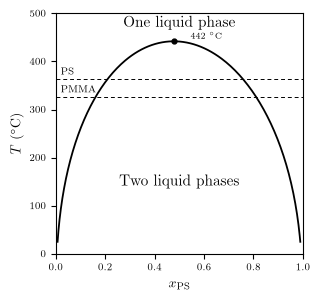

In [ ]:
# --- Print art: Illustration 11.2-6's phase diagram -------------------------
#   pdf/Illustration_11.2-6.pdf -> deliverables/figures/print-bw/ch11/c11uf003.pdf
#
# Replaces the 5e c11uf003.eps, whose dome closes near 380 C because it was drawn
# from the erratum table. Pure black ink throughout: the coexistence curve is the
# heavy line, the two decomposition temperatures are thin dashes, and nothing is
# separated by tint.
#
# The decomposition lines are NOT in the 5e art. They are here because the revised
# text now turns on them -- the consolute point is above both, so the single-phase
# region the dome opens into cannot be reached -- and a reader should be able to see
# that rather than take it on the caption.
fig, ax = plt.subplots(figsize=(3.3, 3.1))

ax.plot(xs, Ts, "-", color="k", lw=1.3)
ax.plot([x_c], [TucC], "o", color="k", ms=3.5)

# Bare polymer names, not "PS decomposes": at 327 C the dome's left branch is already
# at x = 0.16, and any phrase long enough to say "decomposes" runs straight through the
# coexistence curve. The caption carries the meaning instead -- c11.docx now reads
# "...phase diagram. The dashed lines are the reported decomposition temperatures."
ax.axhline(364.0, color="k", lw=0.7, ls=(0, (4, 3)))
ax.text(0.02, 369, "PS", fontsize=7, ha="left", va="bottom")
ax.axhline(327.0, color="k", lw=0.7, ls=(0, (4, 3)))
ax.text(0.02, 332, "PMMA", fontsize=7, ha="left", va="bottom")

ax.text(0.545, 444, rf"{TucC:.0f} $^\circ$C", fontsize=6, ha="left", va="bottom")
# The region labels are SHORTER than the 5e's and set much larger, and the two go
# together. The 5e writes "Single liquid molten polymer phase" and "Two phase polymers";
# 34 characters will not fit across a 3.3 in axes above about 8 pt, and at 8 pt LaTeX
# drops to CMR8 -- and at 6.5 pt to CMR6, Computer Modern's small optical sizes, which
# are drawn wider and looser on purpose so they survive being set that small. Measured
# interword space: 0.382 em at CMR6, 0.375 at CMR7, 0.364 at CMR8, against CMR10's
# 0.333. A long line of small loose letters gives the eye nothing to group into words
# and reads as though it were monospaced -- which is what the 5e art avoids by setting
# its labels roughly twice as tall for the same line length.
#
# Shortening the text is what buys the size back. The illustration's own prose already
# says the phases are molten polymer, so the labels only have to name the regions.
# It also fixes "Two phase polymers", which wants a hyphen as printed.
ax.text(0.50, 480, "One liquid phase", fontsize=8, ha="center", va="center")
ax.text(0.50, 150, "Two liquid phases", fontsize=8, ha="center", va="center")

ax.set_xlabel(r"$x_{\rm PS}$")
ax.set_ylabel(r"$T$ ($^\circ$C)")
ax.set_xlim(0, 1); ax.set_ylim(0, 500)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, 501, 100))
ax.tick_params(labelsize=7)

fig.canvas.draw()
rend = fig.canvas.get_renderer()
labels = [t for t in ax.texts]
boxes = [(t.get_text(), t.get_window_extent(renderer=rend)) for t in labels]
clash = [(a, b) for i, (a, ba) in enumerate(boxes) for b, bb in boxes[i + 1:]
         if ba.overlaps(bb)]
print("label collisions:", clash if clash else "none")
for name, b in boxes:
    print(f"   {name[:34]:36s} x {b.x0:6.1f}..{b.x1:6.1f}   y {b.y0:6.1f}..{b.y1:6.1f}")
assert not clash, "two labels overlap; move one before staging this art"

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Illustration_11.2-6.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Illustration_11.2-6.pdf")

## Your turn

1. The illustration fixes $N_{\rm PS} = 1500$. Redraw the dome for chains of 500, 1500 and
   3000 monomers. Which way does the consolute temperature move, and does the answer make
   sense in terms of the entropy of mixing per molecule?
2. At what degree of polymerization would PS and PMMA become miscible at 300 °C, a
   temperature at which both survive? Is that a chain length anyone would call a polymer?
3. The Flory parameter here is purely enthalpic, $\chi \propto 1/T$. Real $\chi$ is often
   written $a + b/T$ with an entropic part $a$. Add an $a$ of $-0.05$ and redraw. How
   sensitive is the consolute temperature to a number that small?
4. Problem 11.2-9 asks the same question for SAN + PMMA, and gives molar volumes rather
   than degrees of polymerization. Work it with the machinery here.
5. `binary_lle` returns `None` above the consolute temperature rather than a pair of
   nearly equal compositions. Call it at 500 °C, then call it again with
   `check_tangent=False` and an explicit `guess` close to 0.5. What comes back, and why is
   the default the safer contract?
6. Draw the spinodal (`lle.spinodal`) inside the dome you just plotted. The gap between
   the two curves is the metastable region — the compositions a melt can be quenched into
   and hold, for a while, before it separates.